# 07 - Model Evaluation & Comparison
NFL Play-Type Prediction (2016-2023)
Goal: Consolidate and visualise out-of-sample performance of all trained models across feature sets.

## 0. Setup

In [1]:
import sys
sys.path.append('..')

import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches
import seaborn as sns
import os
from pathlib import Path

'''Self modules'''
from config import RESULTS_METRICS, FIGURES_MODELS, PLOT_DPI, PLOT_PALETTE


os.makedirs(FIGURES_MODELS, exist_ok=True)

sns.set_theme(style='whitegrid', palette=PLOT_PALETTE)
palette = sns.color_palette(PLOT_PALETTE)

plt.rcParams['figure.dpi'] = PLOT_DPI
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# model/feature-set ordering and colour map
MODEL_ORDER = ['LogisticRegression', 'XGBoost', 'FNN', 'ResFNN', 'TabNet']
FS_ORDER    = ['mini', 'comprehensive', 'maxi']
PALETTE     = dict(zip(MODEL_ORDER, sns.color_palette('hls', len(MODEL_ORDER))))

METRICS = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
METRIC_LABELS = {
    'accuracy':  'Accuracy',
    'precision': 'Precision',
    'recall':    'Recall',
    'f1':        'F1 Score',
    'roc_auc':   'ROC-AUC',
}

print('Setup complete.')

Setup complete.


## 1. Load & Clean Results

In [2]:
raw = pd.read_csv(RESULTS_METRICS)

# fix double-decimal typos (e.g. '0.0.7196' -> '0.7196')
def fix_double_decimal(val):
    if isinstance(val, str):
        val = re.sub(r'(\d+)\.0\.(\d+)', r'\1.\2', val)
    return val

for col in METRICS:
    raw[col] = raw[col].apply(fix_double_decimal).astype(float)

# enforce ordering for consistent plot layout
raw['model']       = pd.Categorical(raw['model'],       categories=MODEL_ORDER, ordered=True)
raw['feature_set'] = pd.Categorical(raw['feature_set'], categories=FS_ORDER,    ordered=True)
df = raw.sort_values(['model', 'feature_set']).reset_index(drop=True)

print(f'Rows loaded: {len(df)}')
display(df.style
    .format({m: '{:.4f}' for m in METRICS})
    .background_gradient(subset=['roc_auc'], cmap='YlGn')
    .set_caption('Table 1 - Full results summary')
)

Rows loaded: 15


,model,feature_set,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,mini,0.7055,0.7033,0.7055,0.6991,0.7574
1,LogisticRegression,comprehensive,0.7081,0.7056,0.7081,0.7056,0.7620
2,LogisticRegression,maxi,0.7072,0.7070,0.7072,0.7071,0.7639
3,XGBoost,mini,0.7133,0.7120,0.7133,0.7063,0.7782
4,XGBoost,comprehensive,0.7215,0.7193,0.7215,0.7175,0.7919
5,XGBoost,maxi,0.7307,0.7287,0.7307,0.7279,0.8049
6,FNN,mini,0.7135,0.7115,0.7135,0.7080,0.7757
7,FNN,comprehensive,0.7196,0.7175,0.7196,0.7152,0.7872
8,FNN,maxi,0.7182,0.7158,0.7182,0.7147,0.7839
9,ResFNN,mini,0.7087,0.7124,0.7087,0.7099,0.7771


## 2. Per-Metric Comparison

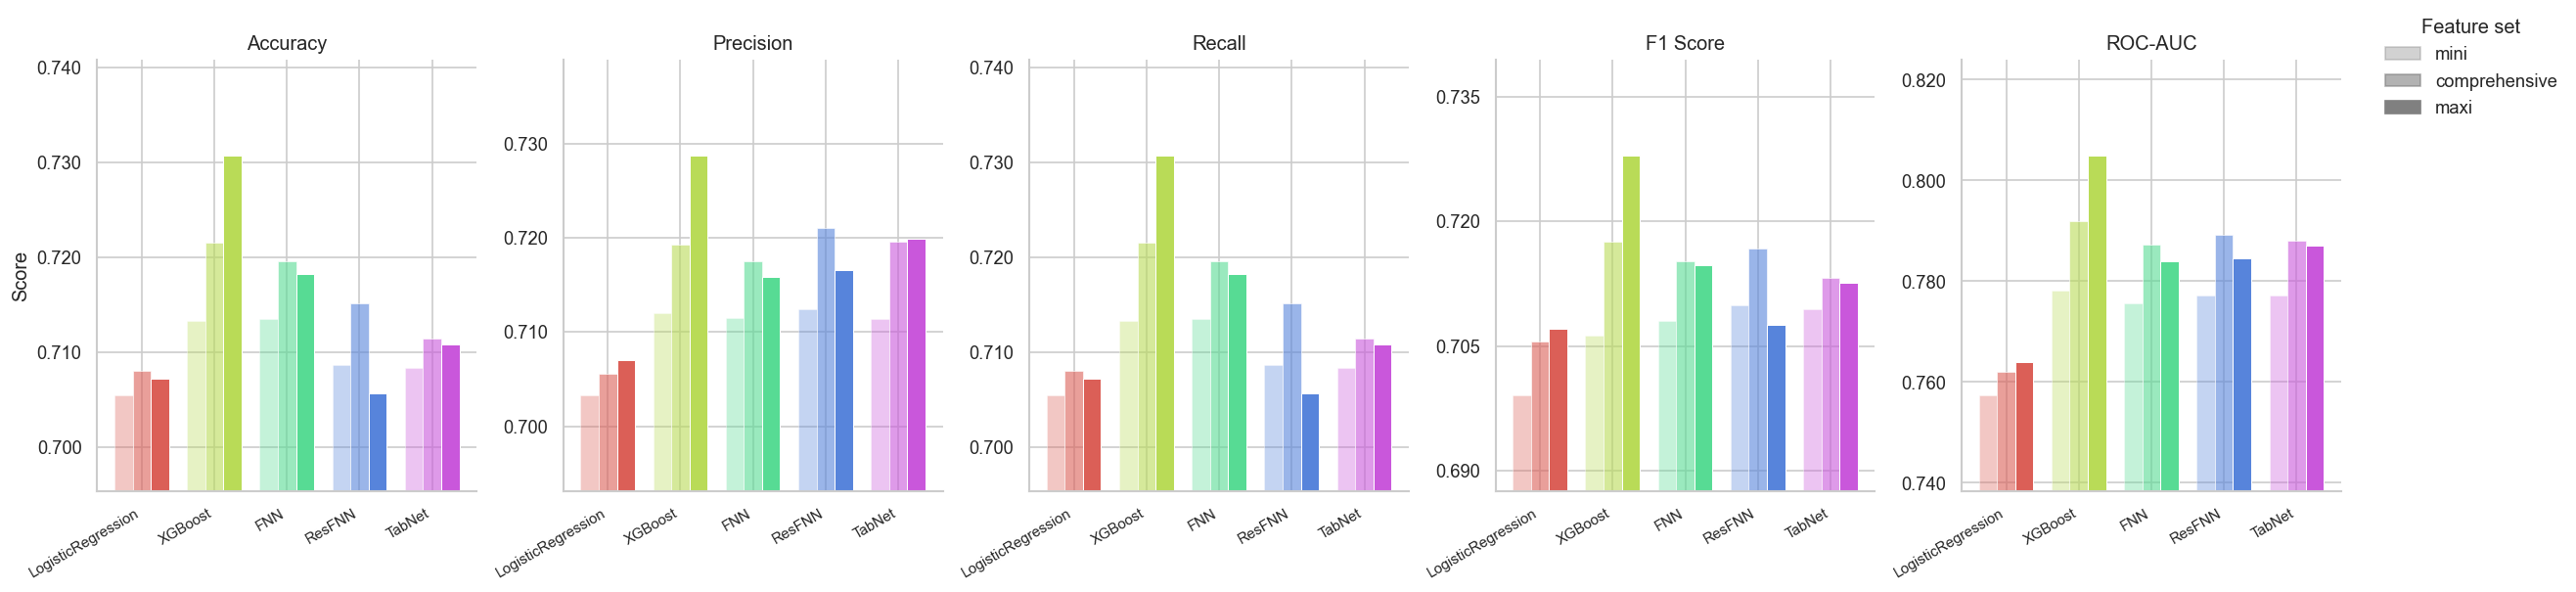

In [3]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(22, 5), sharey=False)

x     = np.arange(len(MODEL_ORDER))
width = 0.25

for ax, metric in zip(axes, METRICS):
    for i, fs in enumerate(FS_ORDER):
        subset = df[df['feature_set'] == fs].set_index('model').reindex(MODEL_ORDER)
        vals   = subset[metric].values
        for j, (val, model) in enumerate(zip(vals, MODEL_ORDER)):
            ax.bar(
                x[j] + (i - 1) * width, val, width,
                color=PALETTE[model],
                alpha=[0.35, 0.6, 1][i],   # mini=clear, comprehensive=middle, maxi=full
                edgecolor='white', linewidth=0.6
            )

    # formatting
    all_vals = df[metric].dropna()
    pad = (all_vals.max() - all_vals.min()) * 0.4
    ax.set_ylim(all_vals.min() - pad, all_vals.max() + pad)
    ax.set_title(METRIC_LABELS[metric])
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    if ax == axes[0]:
        ax.set_ylabel('Score')

# legend: feature sets als alpha-Abstufung einer Beispielfarbe
fs_handles = [
    plt.Rectangle((0, 0), 1, 1,
                  color='grey', alpha=[0.35, 0.6, 1][i],
                  label=fs)
    for i, fs in enumerate(FS_ORDER)
]
fig.legend(handles=fs_handles, title='Feature set', loc='upper right',
           bbox_to_anchor=(1.0, 1.02), frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_MODELS, 'fig1_metric_comparison.png'), bbox_inches='tight')
fig.subplots_adjust(right=0.91)
plt.show()

## 4. Feature Set Gain

Tracks how each model's performance changes as the feature space expands.
A rising line indicates the model benefits from additional features, while a flat or falling line suggests diminishing returns or noise sensitivity.

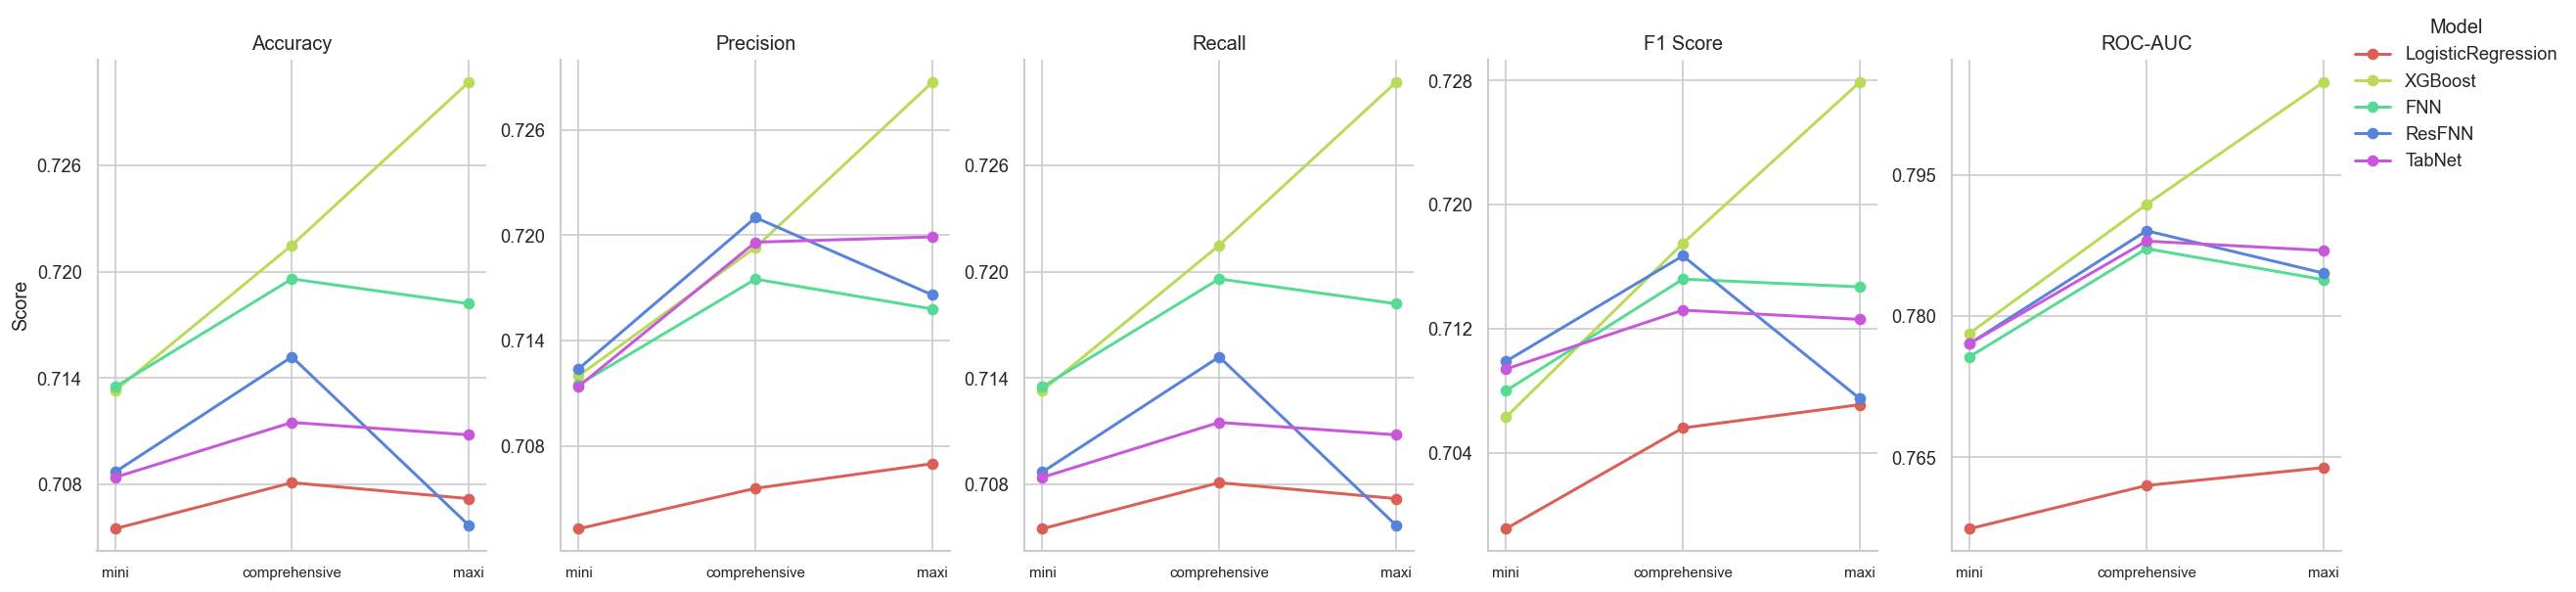

In [4]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(22, 5), sharey=False)

for ax, metric in zip(axes, METRICS):
    for model in MODEL_ORDER:
        subset = (
            df[df['model'] == model]
            .set_index('feature_set')
            .reindex(FS_ORDER)
        )
        vals = subset[metric].values
        ax.plot(FS_ORDER, vals, color=PALETTE[model],
                marker='o', linewidth=1.8, markersize=6, label=model)

    ax.set_title(METRIC_LABELS[metric])
    ax.set_xlabel('')
    ax.set_xticks(range(len(FS_ORDER)))
    ax.set_xticklabels(FS_ORDER, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    if ax == axes[0]:
        ax.set_ylabel('Score')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Model', loc='upper right',
           bbox_to_anchor=(1.0, 1.02), frameon=False)

fig.tight_layout()
fig.subplots_adjust(right=0.91)
fig.savefig(os.path.join(FIGURES_MODELS, 'fig2_feature_set_gain.png'), bbox_inches='tight')
plt.show()

## 5. ROC-AUC Ranking

Ranks all model–feature-set combinations by ROC-AUC, the primary threshold-independent discrimination metric.
Horizontal bars indicate the performance range of each model family across feature sets.

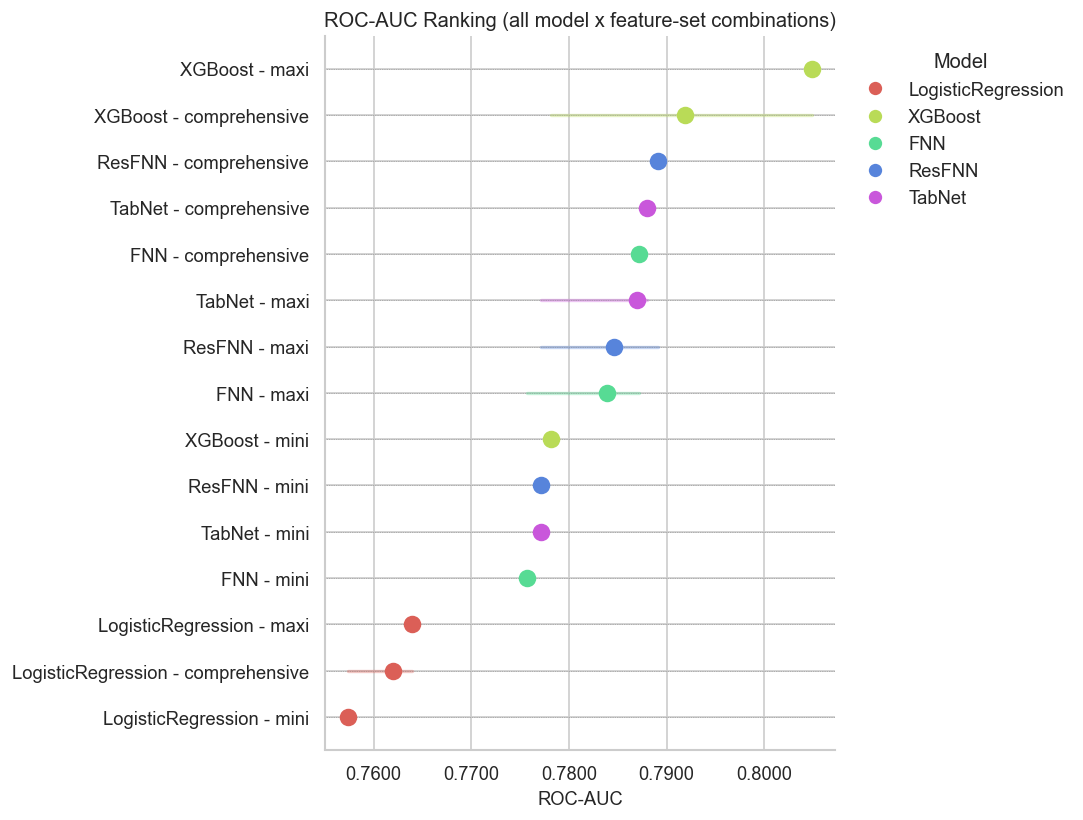

In [7]:
# ranked dot-plot — all model x feature-set combinations
ranked = df[['model', 'feature_set', 'roc_auc']].copy()
ranked['label'] = ranked['model'].astype(str) + ' - ' + ranked['feature_set'].astype(str)
ranked = ranked.sort_values('roc_auc', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 7))

for _, row in ranked.iterrows():
    color = PALETTE[row['model']]
    ax.scatter(row['roc_auc'], row['label'], color=color, s=90, zorder=3)
    ax.axhline(y=row['label'], color='grey', linewidth=0.4, linestyle=':', zorder=1)

# range bars per model family
for model in MODEL_ORDER:
    sub = ranked[ranked['model'] == model]
    if len(sub) < 2:
        continue
    y_positions = sub['label'].tolist()
    x_min, x_max = sub['roc_auc'].min(), sub['roc_auc'].max()
    y_mid = y_positions[len(y_positions) // 2]
    ax.plot([x_min, x_max], [y_mid, y_mid],
            color=PALETTE[model], linewidth=2, alpha=0.35, zorder=2)

# legend (model families)
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=PALETTE[m], markersize=9, label=m)
    for m in MODEL_ORDER
]
ax.legend(handles=legend_handles, title='Model', frameon=False,
          bbox_to_anchor=(1.01, 1), loc='upper left')

ax.set_xlabel('ROC-AUC', fontsize=11)
ax.set_title('ROC-AUC Ranking (all model x feature-set combinations)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

fig.tight_layout()
fig.subplots_adjust(right=0.88)
fig.savefig(os.path.join(FIGURES_MODELS, 'fig3_roc_auc_ranking.png'), bbox_inches='tight')
plt.show()

## 5. Summary Statistics

In [6]:
# per-model summary (mean +/- std across feature sets)
summary = (
    df.groupby('model', observed=True)[METRICS]
      .agg(['mean', 'std'])
)
summary.columns = [f'{m}_{s}' for m, s in summary.columns]

pretty = pd.DataFrame(index=MODEL_ORDER)
for m in METRICS:
    pretty[METRIC_LABELS[m]] = (
        summary[f'{m}_mean'].map('{:.4f}'.format) + ' +/- ' +
        summary[f'{m}_std'].map('{:.4f}'.format)
    )

print('Table 2 - Model summary (mean +/- std across feature sets)')
display(pretty)

# best single configuration
best_row = df.loc[df['roc_auc'].idxmax()]
print(f"\nBest configuration: {best_row['model']} - {best_row['feature_set']}")
for m in METRICS:
    print(f"  {METRIC_LABELS[m]}: {best_row[m]:.4f}")

Table 2 - Model summary (mean +/- std across feature sets)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
LogisticRegression,0.7069 +/- 0.0013,0.7053 +/- 0.0019,0.7069 +/- 0.0013,0.7039 +/- 0.0043,0.7611 +/- 0.0033
XGBoost,0.7218 +/- 0.0087,0.7200 +/- 0.0084,0.7218 +/- 0.0087,0.7172 +/- 0.0108,0.7917 +/- 0.0134
FNN,0.7171 +/- 0.0032,0.7149 +/- 0.0031,0.7171 +/- 0.0032,0.7126 +/- 0.0040,0.7823 +/- 0.0059
ResFNN,0.7099 +/- 0.0049,0.7167 +/- 0.0043,0.7099 +/- 0.0049,0.7114 +/- 0.0048,0.7836 +/- 0.0061
TabNet,0.7102 +/- 0.0016,0.7170 +/- 0.0048,0.7102 +/- 0.0016,0.7117 +/- 0.0020,0.7840 +/- 0.0060



Best configuration: XGBoost - maxi
  Accuracy: 0.7307
  Precision: 0.7287
  Recall: 0.7307
  F1 Score: 0.7279
  ROC-AUC: 0.8049


## 6. Discussion

Feature set impact.
Expanding from mini to comprehensive yields consistent but modest gains for all model families. Moving to maxi provides additional uplift primarily for XGBoost, which benefits most from the richer feature space (vegas probabilities, drive-level aggregates, team identifiers). Neural approaches (FNN, ResFNN, TabNet) show diminishing returns or slight degradation on maxi, suggesting that regularisation and architecture capacity may need revisiting for very high-dimensional inputs.

Model ranking.
XGBoost achieves the best overall ROC-AUC (maxi: 0.8049), outperforming all neural architectures. Among the deep learning models, FNN and ResFNN on comprehensive are competitive. TabNet's advantage of built-in feature selection does not translate into higher accuracy here, possibly because the feature selection stage already removed low-signal columns.

Logistic Regression baseline.
Despite its simplicity, Logistic Regression remains within ~2-3 pp ROC-AUC of the best neural model, underscoring that the raw feature signal — especially win probability and score differential — is already largely linear.

Practical takeaway.
For deployment, XGBoost (maxi) is the recommended model. If latency or interpretability is critical, XGBoost (comprehensive) offers nearly identical accuracy with a smaller feature pipeline.